In [ ]:
!pip install gensim
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.7 MB/s eta 0:00:00


In [ ]:
text=["king is a brave man", "king is a kind man","queen is beautiful woman", "rose is red", "milk is white", "chennai is a city in tamilnadu", "mumbai is a city in maharahtra"]

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
corpus=[word_tokenize(sentence.lower()) for sentence in text]
print(corpus)

[['king', 'is', 'a', 'brave', 'man'], ['king', 'is', 'a', 'kind', 'man'], ['queen', 'is', 'beautiful', 'woman'], ['rose', 'is', 'red'], ['milk', 'is', 'white'], ['chennai', 'is', 'a', 'city', 'in', 'tamilnadu'], ['mumbai', 'is', 'a', 'city', 'in', 'maharahtra']]


In [ ]:

model=Word2Vec(sentences=corpus,vector_size=2, window=2, min_count=1, sg=0) #1 skipgram, 0 = CBOW)
# Word Embedding Example
print("Word Embedding of King", model.wv["king"])
print("Word Embedding of Queen", model.wv["queen"])

Word Embedding of King [ 0.36902523 -0.07667357]
Word Embedding of Queen [ 0.47690594 -0.36595833]


In [ ]:
print(model.wv.most_similar("king"))

[('red', 0.9590038657188416), ('milk', 0.9500609636306763), ('brave', 0.9095945358276367), ('queen', 0.9005947709083557), ('tamilnadu', 0.8591989278793335), ('white', 0.6886523962020874), ('city', 0.40692993998527527), ('a', 0.30556371808052063), ('rose', -0.3592568635940552), ('chennai', -0.49236369132995605)]


In [ ]:
print(model.wv.similarity("king","queen"))
dwp=model.wv.most_similar(["king","queen"],["red"])
print(dwp)

0.9005948
[('brave', 0.963983952999115), ('milk', 0.8885349631309509), ('tamilnadu', 0.7671669721603394), ('white', 0.5649228096008301), ('city', 0.25688865780830383), ('a', 0.15066532790660858), ('chennai', -0.3480724096298218), ('kind', -0.4914030134677887), ('rose', -0.5027357339859009), ('in', -0.5257489085197449)]


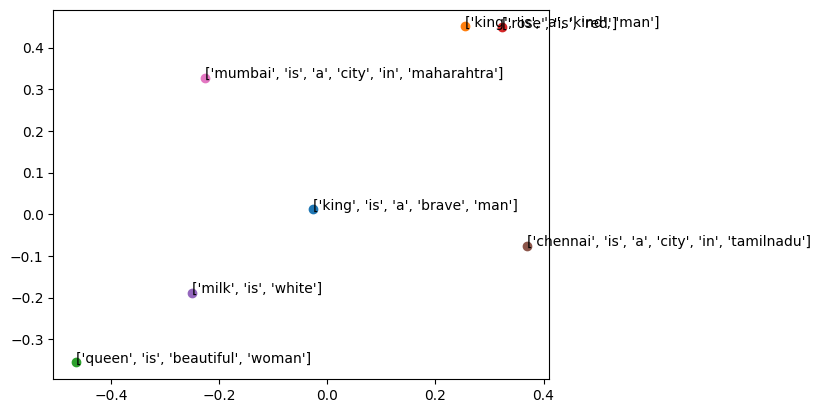

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words=list(model.wv.index_to_key)
result=model.wv[words]
for i,word in enumerate(corpus):
	plt.scatter(result[i,0], result[i,1])
	plt.text(result[i,0], result[i,1], word)
plt.show()


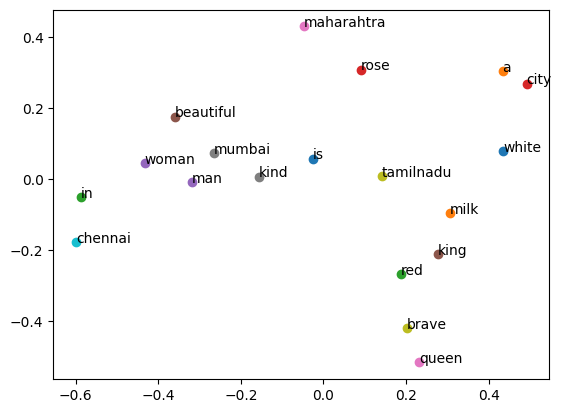

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words=list(model.wv.index_to_key)
vectors=model.wv[words]


pca=PCA(n_components=2)

result=pca.fit_transform(vectors)

for i,word in enumerate(words):
	plt.scatter(result[i,0], result[i,1])
	plt.text(result[i,0], result[i,1], word)
plt.show()
